# Bit Math
This is basically mathematical tricks using bits to optimize calculations.

# 1. Number of Set Bits (Hamming Weight)
# Difficulty: 🟢 Low

Problem Statement:

Write a function that takes a 32-bit unsigned integer and returns the number of '1' bits it has (also known as the Hamming weight).

Example 1:
```
Input: n = 11
Output: 3
Explanation: Binary representation is 00000000000000000000000000001011
Has three '1' bits
```
```
Example 2:
Input: n = 128
Output: 1
Explanation: Binary is 00000000000000000000000010000000
Has one '1' bit
```
```
Example 3:
Input: n = 4294967293
Output: 31
Explanation: Binary is 11111111111111111111111111111101
Has thirty-one '1' bits
Constraints:

The input must be a binary string of length 32

In [ ]:
#Brute Force Approach (Convert to Binary String, Count '1's)
def hamming_weight_brute(n):
    # Convert to binary string and count '1's
    binary_str = bin(n)  # Returns '0b1011' for n=11
    return binary_str.count('1')

print(hamming_weight_brute(11))           # Output: 3
print(hamming_weight_brute(128))          # Output: 1
print(hamming_weight_brute(4294967293))   # Output: 31

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(log n) : bin() converts number to binary string
#                    number with value n has log₂(n) bits
#                    count() scans all bits
# avg   → O(log n) : bin() conversion: O(log n) to generate string
#                    count(): O(log n) to scan string
#                    total = O(log n) + O(log n) = O(log n)
# worst → O(log n) : even large n like 2^32-1 has 32 bits
#                    since n is 32-bit integer: O(32) = O(1) technically
#                    but for general n: O(log n)
# space → O(log n) : binary string stores log₂(n) characters
#                    for 32-bit: O(32) = O(1)

#best time complexity    - O(log n)
#average time complexity - O(log n)
#worst time complexity   - O(log n)
#space complexity        - O(log n)


3
1
31


In [ ]:
#Optimized Approach 1 (Bit Shifting and Masking)
def hamming_weight_shift(n):
    count = 0
    for i in range(32):  # 32-bit integer
        if n & 1:  # Check if least significant bit is 1
            count += 1
        n >>= 1    # Right shift by 1 (divide by 2)
    return count

print(hamming_weight_shift(11))           # Output: 3
print(hamming_weight_shift(128))          # Output: 1

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : always loops exactly 32 times regardless of n
#                  32 iterations × O(1) per iteration = O(32) = O(1)
# avg   → O(1)   : fixed 32 iterations, no early exit
#                  each iteration: one AND, one shift, one comparison = O(1)
# worst → O(1)   : same 32 iterations whether n=1 or n=2^32-1
# space → O(1)   : only count variable, no extra structures

# VISUALIZATION for n=11 (binary: 1011):
# Iteration 0: n=1011, n&1=1, count=1, n>>=1011>>1=0101
# Iteration 1: n=0101, n&1=1, count=2, n>>=0101>>1=0010
# Iteration 2: n=0010, n&1=0, count=2, n>>=0010>>1=0001
# Iteration 3: n=0001, n&1=1, count=3, n>>=0001>>1=0000
# ... (28 more iterations with n=0)
# Result: 3

#best time complexity    - O(1)
#average time complexity - O(1)
#worst time complexity   - O(1)
#space complexity        - O(1)

3
1


In [ ]:
#Optimized Approach 2 (Brian Kernighan's Algorithm - Best!)
def hamming_weight_optimized(n):
    count = 0
    while n:
        n &= (n - 1)  # Clear the rightmost set bit
        count += 1
    return count

print(hamming_weight_optimized(11))           # Output: 3
print(hamming_weight_optimized(128))          # Output: 1
print(hamming_weight_optimized(4294967293))   # Output: 31

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(1)   : n has only 1 set bit (e.g., n=128=10000000)
#                  loop runs once, clears bit, n becomes 0
# avg   → O(k)   : where k = number of set bits
#                  loop runs exactly k times (once per set bit)
#                  for average n with k/2 bits set: O(k/2) = O(k)
# worst → O(k)   : all 32 bits set (n=2^32-1=11111...1111)
#                  loop runs 32 times, but k=32 so O(32) = O(1)
#                  generally O(k) where k ≤ 32
# space → O(1)   : only count variable

# WHY IT WORKS (Brian Kernighan's Algorithm):
# n - 1 flips all bits after the rightmost set bit (including it)
# n & (n-1) clears the rightmost set bit
#
# VISUALIZATION for n=11 (binary: 1011):
# Iteration 1: n=1011, n-1=1010, n&(n-1)=1010, count=1
# Iteration 2: n=1010, n-1=1001, n&(n-1)=1000, count=2
# Iteration 3: n=1000, n-1=0111, n&(n-1)=0000, count=3
# n=0, exit loop
# Result: 3 (only 3 iterations for 3 set bits!)

# KEY ADVANTAGE: Loop runs only k times (k = set bits)
# Much better than 32 iterations when k is small!

#best time complexity    - O(1)
#average time complexity - O(k) where k = set bits
#worst time complexity   - O(k) where k ≤ 32 = O(1)
#space complexity        - O(1)

3
1
31


## 2. Power of a Number (x^n) - Fast Exponentiation
**Difficulty: 🟡 Medium**

**Problem Statement:**
Implement pow(x, n), which calculates x raised to the power n (i.e., x^n) using fast exponentiation (also called binary exponentiation).

**Example 1:**
```
Input: x = 2.0, n = 10
Output: 1024.0
Explanation: 2^10 = 1024
```

**Example 2:**
```
Input: x = 2.1, n = 3
Output: 9.261
Explanation: 2.1^3 = 2.1 × 2.1 × 2.1 = 9.261
```

**Example 3:**
```
Input: x = 2.0, n = -2
Output: 0.25
Explanation: 2^(-2) = 1/(2^2) = 1/4 = 0.25

Constraints:

-100.0 < x < 100.0
-2^31 ≤ n ≤ 2^31 - 1
Either x is not zero or n > 0

In [ ]:
#Brute Force Approach (Iterative Multiplication)
def my_pow_brute(x, n):
    if n == 0:
        return 1.0

    # Handle negative exponent
    negative = n < 0
    n = abs(n)

    result = 1.0
    for _ in range(n):
        result *= x

    return 1 / result if negative else result

print(my_pow_brute(2.0, 10))   # Output: 1024.0
print(my_pow_brute(2.1, 3))    # Output: 9.261
print(my_pow_brute(2.0, -2))   # Output: 0.25

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(n)   : n=0 returns immediately O(1)
#                  but for n>0, always loops n times
# avg   → O(n)   : loop runs exactly n iterations
#                  each iteration: one multiplication O(1)
#                  total = n × O(1) = O(n)
# worst → O(n)   : large n like 10^9 requires billion multiplications
#                  absolutely impractical for large n
# space → O(1)   : only result variable, no recursion

#best time complexity    - O(n)
#average time complexity - O(n)
#worst time complexity   - O(n)
#space complexity        - O(1)

1024.0
9.261000000000001
0.25


In [ ]:
#Optimized Approach (Fast Exponentiation - Recursive)
def my_pow_recursive(x, n):
    if n == 0:
        return 1.0

    # Handle negative exponent
    if n < 0:
        x = 1 / x
        n = -n

    def fast_power(base, exp):
        if exp == 0:
            return 1.0

        # Divide exponent by 2
        half = fast_power(base, exp // 2)

        if exp % 2 == 0:
            # Even exponent: x^n = (x^(n/2))^2
            return half * half
        else:
            # Odd exponent: x^n = x × (x^(n/2))^2
            return base * half * half

    return fast_power(x, n)

print(my_pow_recursive(2.0, 10))   # Output: 1024.0
print(my_pow_recursive(2.1, 3))    # Output: 9.261
print(my_pow_recursive(2.0, -2))   # Output: 0.25

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(log n) : n=0 or n=1 returns in O(1)
#                    but for n>1, always recurses log₂(n) times
# avg   → O(log n) : each recursive call halves the exponent
#                    recursion depth = log₂(n)
#                    example: 2^10 → 2^5 → 2^2 → 2^1 → done (4 calls)
#                    recurrence: T(n) = T(n/2) + O(1) = O(log n)
# worst → O(log n) : even n=10^9 requires only ~30 recursive calls
#                    log₂(10^9) ≈ 30
# space → O(log n) : recursion stack depth = log₂(n)

# WHY IT WORKS (Binary Exponentiation):
# Key insight: x^n = (x^(n/2))^2 if n is even
#              x^n = x × (x^(n/2))^2 if n is odd
#
# VISUALIZATION for x=2, n=10:
# 2^10 = (2^5)^2
# 2^5 = 2 × (2^2)^2
# 2^2 = (2^1)^2
# 2^1 = 2
# Work backwards: 2^1=2, 2^2=4, 2^5=2×16=32, 2^10=32×32=1024

#best time complexity    - O(log n)
#average time complexity - O(log n)
#worst time complexity   - O(log n)
#space complexity        - O(log n)




1024.0
9.261000000000001
0.25


In [ ]:
#Optimized Approach (Fast Exponentiation - Iterative with Bit Manipulation)
def my_pow_iterative(x, n):
    if n == 0:
        return 1.0

    # Handle negative exponent
    if n < 0:
        x = 1 / x
        n = -n

    result = 1.0
    current_product = x

    while n > 0:
        if n & 1:  # If current bit is 1 (odd)
            result *= current_product
        current_product *= current_product  # Square the base
        n >>= 1  # Right shift (divide by 2)

    return result

print(my_pow_iterative(2.0, 10))   # Output: 1024.0
print(my_pow_iterative(2.1, 3))    # Output: 9.261
print(my_pow_iterative(2.0, -2))   # Output: 0.25

# HOW COMPLEXITIES ARE DERIVED:
# best  → O(log n) : loop runs log₂(n) times until n becomes 0
#                    each iteration halves n via right shift
# avg   → O(log n) : while loop iterations = number of bits in n = log₂(n)
#                    each iteration: O(1) operations (multiply, shift, AND)
#                    total = log₂(n) × O(1) = O(log n)
# worst → O(log n) : even n=2^31-1 has only 31 bits
#                    loop runs at most 31 times = O(log n)
# space → O(1)     : only result and current_product variables
#                    no recursion stack

# WHY IT WORKS (Binary Exponentiation with Bits):
# Think of n in binary: n = b_k × 2^k + b_(k-1) × 2^(k-1) + ... + b_0 × 2^0
# x^n = x^(b_k × 2^k) × x^(b_(k-1) × 2^(k-1)) × ... × x^(b_0 × 2^0)
# We process each bit: if bit is 1, multiply result by current_product
#
# VISUALIZATION for x=2, n=10 (binary: 1010):
# Iteration 1: n=1010, n&1=0, result=1, current=2, n>>=0101
# Iteration 2: n=0101, n&1=1, result=1×4=4, current=4×4=16, n>>=0010
# Iteration 3: n=0010, n&1=0, result=4, current=16×16=256, n>>=0001
# Iteration 4: n=0001, n&1=1, result=4×256=1024, current=256×256, n>>=0000
# Result: 1024 ✓
#
# Explanation: 10 in binary is 1010 = 8 + 2 = 2^3 + 2^1
# So 2^10 = 2^(2^3) × 2^(2^1) = 2^8 × 2^2 = 256 × 4 = 1024

#best time complexity    - O(log n)
#average time complexity - O(log n)
#worst time complexity   - O(log n)
#space complexity        - O(1)

1024.0
9.261000000000001
0.25


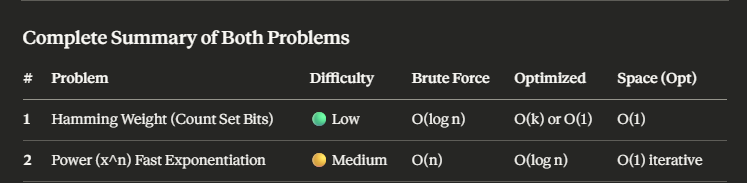